# **MÓDULO 32 - Exercício**
# Random Forest


Nesta tarefa, vocês vão trabalhar com uma base de dados de avaliações de vinhos, onde o objetivo é prever a pontuação dos vinhos usando o algoritmo de Random Forest para classificação multiclasse.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/winequality-red.csv", delimiter=',')

df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


**Vamos conhecer nossa base:**

Características dos Vinhos (Features)

Fixed Acidity: Acidez fixa do vinho.

Volatile Acidity: Acidez volátil do vinho.

Citric Acid: Quantidade de ácido cítrico no vinho.

Residual Sugar: Açúcar residual presente no vinho.

Chlorides: Nível de cloretos no vinho.

Free Sulfur Dioxide: Dióxido de enxofre livre no vinho.

Total Sulfur Dioxide: Quantidade total de dióxido de enxofre no vinho.

Density: Densidade do vinho.

pH: Nível de pH do vinho.

Sulphates: Quantidade de sulfatos no vinho.

Alcohol: Teor alcoólico do vinho.



**Variável de Saída (Target):**

Quality: Pontuação do vinho baseada em dados sensoriais, variando de 0 a 10.


Esta abordagem permitirá que vocês explorem como diferentes características químicas influenciam a qualidade dos vinhos e como o Random Forest pode ser usado para fazer previsões precisas com base nesses dados.

# 1 - Realize a primeira etapa de pré processamento dos dados.

A) Verifique os tipos de dados.


B) Verifique os dados faltantes, se houver dados faltantes faça a substituição ou remoção justificando sua escolha.

In [ ]:
# Verificando os tipos de dados
df.dtypes

,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


In [ ]:
# Verificando se a base possui dados faltantes
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


* Os tipos de dados condizem com suas variaveis, sendo do tipo 'float' para as caracteristicas dos vinhos e do tipo 'int' para a nota final dos vinhos.
* Após a analise inicial não foi detectado dados faltantes na base de dados.

# 2 - Realize a segunda e terceita etapa de pré processamento dos dados.

A) Utilize a função describe para identificarmos outliers e verificarmos a distribuição dos dados.

B) Verifique o balanceamento da váriavel Target.

C)  Plote o gráfico ou a tabela e indique as variáveis que te parecem mais "fortes" na correlação para nosso modelo.

D) Crie um novo dataframe apenas com as váriaveis que parecem ter maior correlação com a target. (Negativa ou positiva)


In [ ]:
# Analisando distribuição dos dados
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


* Algumas variaveis apresentam outliers, mas por se tartarem de indices das caracteristicas dos vinhos, optei por nao retira-los
* Apesar de trabalharem em escalas diferentes, as variaveis aparentam estar balanceadas

In [ ]:
# Verificando o balanceamento
df['quality'].value_counts()

,count
quality,
5,681
6,638
7,199
4,53
8,18
3,10


Os dados da variavel target estao bem desbalanceadas, com maior incidencia nas notas 5, 6 e 7. para uma melhor performance do modelo, o ideal seria fazer o balanceamento.

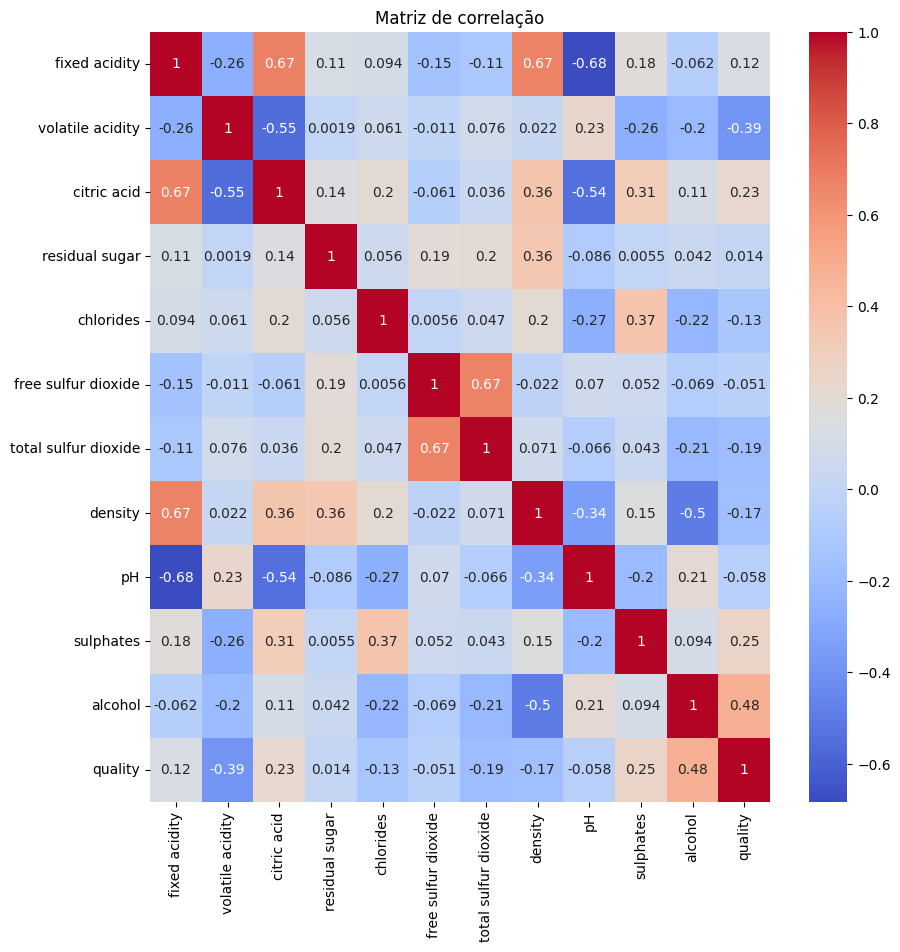

In [ ]:
# Fazendo a correlação dos dados
correlation_matriz = df.corr()
# Plotando a matriz de correlação
plt.figure(figsize=(10,10))
sns.heatmap(correlation_matriz, annot=True, cmap='coolwarm')
plt.title('Matriz de correlação')
plt.show()

De acordo com a matriz, em relação a variavel target, as variaveis 'volatile acidity', 'sulphates' e 'alcohol' são as que possuem maiores correlações. Porem eu defini uma regua nas variaveis com correlação maior que 2, seja positivo ou negativo, dando um desconto para a variavel 'total sulfur dioxide'. Creio que as demais variaveis tbm possuem uma correlação notavel para o modelo.

In [ ]:
# Criando uma nova base com as variaveis de maior correlação
base = df.copy()
base.drop(columns=['fixed acidity', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'density', 'pH'], inplace=True)
# Verificando a nova base
base

,volatile acidity,citric acid,total sulfur dioxide,sulphates,alcohol,quality
0,0.700,0.00,34.0,0.56,9.4,5
1,0.880,0.00,67.0,0.68,9.8,5
2,0.760,0.04,54.0,0.65,9.8,5
3,0.280,0.56,60.0,0.58,9.8,6
4,0.700,0.00,34.0,0.56,9.4,5
...,...,...,...,...,...,...
1594,0.600,0.08,44.0,0.58,10.5,5
1595,0.550,0.10,51.0,0.76,11.2,6
1596,0.510,0.13,40.0,0.75,11.0,6
1597,0.645,0.12,44.0,0.71,10.2,5


Como explicado anteriormente, criei uma nova base para ser aplicado ao modelo apenas com as variaveis com correlação maior que 2

# 3 - Preparação Final dos Dados

A) Separe a base em X(Features) e Y(Target)

B) Separe a base em treino e teste.


In [ ]:
# Separando a base em X e Y
X = base.drop(columns=['quality'], axis=1) # Base sem a variavel target
Y = base['quality'] # Base apenas com a variavel target

In [ ]:
# Separando a base de treino e teste
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 4 - Modelagem

A) Inicie e treine o modelo de Random Forest

B) Aplique a base de teste o modelo.


In [ ]:
# Iniciando o modelo Random Forest
winequality_RFmodel = RandomForestClassifier(random_state=42)

In [ ]:
# Treinando o modelo
winequality_RFmodel.fit(X_train, Y_train)

RandomForestClassifier(random_state=42)

In [ ]:
Y_pred = winequality_RFmodel.predict(X_test)

# 5 - Avaliação

A) Avalie as principais métricas da Claissificação e traga insights acerca do resultado, interprete os valores achados.

B) Você nota que o modelo teve dificuldade para prever alguma classe? Se sim, acredita que tenha relação com o balanceamento dos dados? Explique.


In [ ]:
# Avaliando o modelo
accuracy = accuracy_score(Y_test, Y_pred)
report = classification_report(Y_test, Y_pred)
confusion_mat = confusion_matrix(Y_test, Y_pred)

print("Acurácia:", accuracy)
print("Relatório de Classificação:\n", report)
print("Matriz de Confusão:\n", confusion_mat)

Acurácia: 0.653125
Relatório de Classificação:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.71      0.78      0.74       130
           6       0.62      0.65      0.63       132
           7       0.60      0.50      0.55        42
           8       0.00      0.00      0.00         5

    accuracy                           0.65       320
   macro avg       0.32      0.32      0.32       320
weighted avg       0.62      0.65      0.64       320

Matriz de Confusão:
 [[  0   0   0   1   0   0]
 [  0   0   5   5   0   0]
 [  0   0 102  27   1   0]
 [  0   0  36  86  10   0]
 [  0   1   1  18  21   1]
 [  0   0   0   2   3   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


* O modelo tem uma acuracia de 65%
* As notas 5 e 6 são as que o modelo preve melhor, com f1-score de 0.74 para nota 5 e 0.63 para nota 6
* A nota 7 teve um desempenho moderado com o f1-score de 0.54
* O modelo não conseguiu prever as notas 3, 4 e 8 mostrando que ele nao aprendeu já que possui poucas incidencias com estas notas, possivelmente pelo desbalanceamento dos dados

Devido ao baixo desempenho do modelo, optei por balancear os dados para ver se teremos alguma melhora no desempenho

### Avaliando o modelo com os dados balanceados

In [ ]:
# Fazendo o balanceamento dos dados com o SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, Y_train_balanced = smote.fit_resample(X_train, Y_train)

In [ ]:
# Iniciando o modelo com os dados balanceados
winequalitybalanced_RFmodel = RandomForestClassifier(random_state=42)

In [ ]:
# Treinando o modelo com os dados balanceados
winequalitybalanced_RFmodel.fit(X_train_balanced, Y_train_balanced)

RandomForestClassifier(random_state=42)

In [ ]:
# Fazendo a previsão após o balanceamento dos dados
Y_pred_balanced = winequalitybalanced_RFmodel.predict(X_test)


In [ ]:
# Avaliando o modelo após o balanceamento dos dados
accuracy = accuracy_score(Y_test, Y_pred_balanced)
report = classification_report(Y_test, Y_pred_balanced)
confusion_mat = confusion_matrix(Y_test, Y_pred_balanced)

print("Acurácia:", accuracy)
print("Relatório de Classificação:\n", report)
print("Matriz de Confusão:\n", confusion_mat)

Acurácia: 0.578125
Relatório de Classificação:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.11      0.30      0.16        10
           5       0.72      0.70      0.71       130
           6       0.63      0.48      0.55       132
           7       0.48      0.62      0.54        42
           8       0.11      0.20      0.14         5

    accuracy                           0.58       320
   macro avg       0.34      0.38      0.35       320
weighted avg       0.62      0.58      0.59       320

Matriz de Confusão:
 [[ 0  1  0  0  0  0]
 [ 0  3  4  3  0  0]
 [ 1 11 91 25  1  1]
 [ 0 12 30 64 23  3]
 [ 0  1  1 10 26  4]
 [ 0  0  0  0  4  1]]


* O modelo obteve uma acuracia de 57%, um pouco menor em relação ao modelo com os dados desbalanceados
* As notas 5, 6 e 7 continuam sendo as que o modelo qprendeu mais, sendo o f1-score de 0.71 para nota 5, 0.55 para nota 6 e 0.54 para nota 7
* Apesar da melhora em relação ao modelo com os dados desbalanceados, as notas 3, 4 e 8 ainda possuem um desempenho muito baixo

O modelo apresentou uma leve melhora no desempenho com os dados balanceados, porem ainda possui uma baixa generalização dos dados, havendo muita confusão entre as classes.

# 5 - Melhorando os Hyperparametros

A) Defina o Grid de parametros que você quer testar

B) Inicie e Treine um novo modelo utilizando o random search.

C) Avalie os resultados do modelo.

D) Você identificou melhorias no modelo após aplicar o random search? Justifique.


ps. Essa parte da atividade demorará um pouco para rodar!

In [ ]:
# Definindo a grid de parametros
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

### Aplicando o Random Search no modelo desbalanceado

In [ ]:
# Configurando o Randomized Search na base desbalanceada
random_search = RandomizedSearchCV(
    estimator=winequality_RFmodel,
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    verbose=2,
    random_state=42,
    scoring='accuracy'
)

In [ ]:
# Executando o Randomized Search na base desbalanceada
random_search.fit(X_train, Y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=50; total time=   1.0s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=50; total time=   0.4s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=50; total time=   0.4s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=50; total time=   0.3s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=50; total time=   0.2s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.2s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.2s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=50; t

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 200]},
                   random_state=42, scoring='accuracy', verbose=2)

In [ ]:
# Obtendo os melhores parametros para base desbalanceada
best_params = random_search.best_params_
print(f'Melhores parametros: {best_params}')

Melhores parametros: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10}


### Aplicando o Random Search no modelo balanceado

In [ ]:
# Configurando o Randomized Search na base balanceada
random_search_balanced = RandomizedSearchCV(
    estimator=winequalitybalanced_RFmodel,
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    verbose=2,
    random_state=42,
    scoring='accuracy'
)

In [ ]:
# Executando o Randomized Search na base balanceada
random_search_balanced.fit(X_train_balanced, Y_train_balanced)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=50; total time=   0.3s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=50; total time=   0.3s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=50; total time=   0.3s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=50; total time=   0.3s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=50; total time=   0.3s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.3s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.4s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=50; t

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 200]},
                   random_state=42, scoring='accuracy', verbose=2)

In [ ]:
# Obtendo os melhores parametros para base balanceada
best_params_balanced = random_search_balanced.best_params_
print(f'Melhores parametros: {best_params}')

Melhores parametros: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10}


### Treinando o modelo

In [ ]:
# Treinando o modelo desbalanceado com os melhores hiperparâmetros encontrados acima
winequality_best_rf_model = random_search.best_estimator_
winequality_best_rf_model.fit(X_train, Y_train)

RandomForestClassifier(min_samples_leaf=2, n_estimators=50, random_state=42)

In [ ]:
# Fazendo a previsão no modelo desbalanceado
Y_pred_best = winequality_best_rf_model.predict(X_test)

In [ ]:
# Treinando o modelo balanceado com os melhores hiperparâmetros encontrados acima
winequality_balanced_best_rf_model = random_search_balanced.best_estimator_
winequality_balanced_best_rf_model.fit(X_train_balanced, Y_train_balanced)

RandomForestClassifier(min_samples_leaf=2, n_estimators=50, random_state=42)

In [ ]:
# Fazendo a previsão no modelo balanceado
Y_pred_balanced_best = winequality_balanced_best_rf_model.predict(X_test)

### Avaliação dos modelos

In [ ]:
# Avaliando o modelo desbalanceado
accuracy = accuracy_score(Y_test, Y_pred_best)
report = classification_report(Y_test, Y_pred_best)
conf_matrix = confusion_matrix(Y_test, Y_pred_best)

print(f"Acurácia: {accuracy:.2f}")
print("Relatório de Classificação:\n", report)
print("Matriz de Confusão:\n", conf_matrix)

Acurácia: 0.67
Relatório de Classificação:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.71      0.82      0.76       130
           6       0.64      0.66      0.65       132
           7       0.61      0.48      0.53        42
           8       0.00      0.00      0.00         5

    accuracy                           0.67       320
   macro avg       0.33      0.33      0.32       320
weighted avg       0.63      0.67      0.65       320

Matriz de Confusão:
 [[  0   0   0   1   0   0]
 [  0   0   6   4   0   0]
 [  0   0 107  22   1   0]
 [  0   0  36  87   9   0]
 [  0   0   1  21  20   0]
 [  0   0   0   2   3   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


* O modelo teve uma acuracia superior após aplicar os hiperparametros alcançando 67%
* As notas 5 e 6 ainda são as que o modelo teve a  melhor previsão, com f1-score de 0.76 para nota 5 e 0.65 para nota 6
* A nota 7 teve uma redução no desempenho em relação ao modelo sem os ajustes marcando 0.53 no f1-score
* O modelo ainda não conseguiu prever as notas 3, 4 e 8 mostrando que ele ainda nao aprendeu por nao haver muitos exemplos com estas notas

In [ ]:
# Avaliando o modelo balanceado
accuracy = accuracy_score(Y_test, Y_pred_balanced_best)
report = classification_report(Y_test, Y_pred_balanced_best)
conf_matrix = confusion_matrix(Y_test, Y_pred_balanced_best)

print(f"Acurácia: {accuracy:.2f}")
print("Relatório de Classificação:\n", report)
print("Matriz de Confusão:\n", conf_matrix)

Acurácia: 0.60
Relatório de Classificação:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.11      0.30      0.16        10
           5       0.76      0.75      0.75       130
           6       0.68      0.48      0.56       132
           7       0.48      0.69      0.57        42
           8       0.14      0.20      0.17         5

    accuracy                           0.60       320
   macro avg       0.36      0.40      0.37       320
weighted avg       0.66      0.60      0.62       320

Matriz de Confusão:
 [[ 0  1  0  0  0  0]
 [ 1  3  3  3  0  0]
 [ 2 11 97 18  1  1]
 [ 2 11 27 63 26  3]
 [ 0  1  1  9 29  2]
 [ 0  0  0  0  4  1]]


* O modelo obteve uma melhora na acuracia em relação ao modelo sem os ajustes, alcançando 60%
* As notas 5, 6 e 7 continuam sendo as que o modelo qprendeu melhor, já que possuem mais dados de treinamento
* Apesar da melhora em relação ao modelo com sem os ajustes, as notas 3, 4 e 8 ainda possuem um desempenho muito baixo por consequencia da baixa, ou ate mesmo nulas, dos dados para treinamento

Ambos os modelos apresentaram melhoras após os ajustar os hiperparametros, alcaçando indices maiores de pontuação. Mas após avaliar todos os modelos testados, obtive a conclusão de que a falta de dados para treinamento ainda é o fator principal na perda de desempenho dos modelos. Já que, mesmo após o balanceamento dos dados, o modelo obteve um desempenho melhor com os dados desbalanceados

# 6 - Chegando a perfeição

Baseado em tudo que você já aprendeu até agora, quais outras técnicas você acredita que poderiam ser aplicadas ao modelo para melhorar ainda mais suas previsões?

Apesar de ter aplicado o balanceamento nos dados para treinamento como tentativa de melhorar o desempenho do modelo, acredito que, para as notas que tem pouco ou nenhum exemplo, que foi o fator principal para o baixo desempenho do modelo, poderia ser feito um tratamento para normalizar os dados. Por exemplo, como temos um alto numero de dados para as notas 5 e 6, poderia ser feito, alem do SMOTE para as notas com poucos dados, aplicar o Undersampling para reduzir os dados das notas 5 e 6, já que possuem mais dados para treinamento e assim obter uma melhor balanceamento dos dados.